In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
from collections import OrderedDict
import matplotlib.pyplot as plt
import math
from IPython.display import display, HTML
from scipy.interpolate import interp1d


In [3]:
#### 加载数据 按照文件夹load 或者 给出文件列表
class FCT:

    def __init__(self,*args):
        if (len(args) == 6):
            self.loadFromFolder(args[0], args[1], args[2], args[3], args[4], args[5])
        elif (len(args) == 4):
            self.loadFromFileList(args[0], args[1], args[2], args[3])
        else:
            raise Exception('parameter number must be 6 or 4')

    def loadFromFolder(self, folder, toponame, flownum, loads, algs, normalize_lists):
        self.loads = loads
        self.algs = algs
        self.raw_data = [[0 for i in range(len(loads))] for i in range(len(algs))]
        normalizor = self.expandNormalizedList(normalize_lists)
        for alg_i in range(len(algs)):
            for load_i in range(len(loads)):
                alg = algs[alg_i]
                load = loads[load_i]
                self.raw_data[alg_i][load_i] = \
                    self.parse_trace(folder, \
                                    #  alg+"/tcp_flow_"+str(flownum)+"_"+str(load)+"_"+toponame+".tr", \
                                     "tcp_flow_"+str(flownum)+"_"+str(load)+"_"+toponame+"_"+alg+".tr", \
                                     normalizor)

    def loadFromFileList(self, loads, algs, filelist, normalize_lists):
        if (len(loads) * len(algs) != len(filelist)):
            raise Exception('the filelist is not match with loads and algs')
        self.loads = loads
        self.algs = algs
        self.raw_data = [[0 for i in range(len(loads))] for i in range(len(algs))]
        if len(normalize_lists) != 2 or len(normalize_lists[0]) != len(normalize_lists[1]):
            raise Exception('normalize_lists shoule contains two list with same length')
        normalizor = self.expandNormalizedList(normalize_lists)
        index=0
        for alg_i in range(len(algs)):
            for load_i in range(len(loads)):
                self.raw_data[alg_i][load_i] = self.parse_trace("", filelist[index], normalizor)
                index+=1

    def expandNormalizedList(self, normalize_lists):
        interpolate_function = interp1d(normalize_lists[0], normalize_lists[1], kind='linear')
        max_value = max(normalize_lists[0])
        min_value = min(normalize_lists[0])
        xint = np.linspace(min_value, max_value, max_value - min_value + 1)
        return interpolate_function(xint)


    # Normalized FCT = Actual FCT / min FCT
    # min FCT = flow_size / max bandwidth
    def parse_trace(self, directory, filename, normalizor):
        col = ["tmp_pkts", "flow duration", "fin_fid", "rtt times", \
                   "group_id", "Tw_", "Tp_", "Np_", "?1", "?2", "?3", "?4", "?5", "Average rate", "start time"]
        df = pd.read_csv(directory + filename, sep = ' ', header = None)
        df.columns = col
        # modified v
        max_idx = len(normalizor) - 1
        def safe_lookup(x):
            idx = int(x)
            if idx > max_idx:  # 超出范围保护
                idx = max_idx
            elif idx < 0:
                idx = 0
            return normalizor[idx]

        df["Normalized FCT"] = df["tmp_pkts"].apply(safe_lookup) / df["Average rate"]
        df = df.dropna(subset=["Normalized FCT"])
        # modified ^

        # —— 新增：按 flowid%3 分类 ——
        df["weight_class"] = df["fin_fid"] % 3
        return df

    ## internal
    def plot_one_FCT_mean_mark(self, alg, load, flow_num, isLast=False):
        alg_id = self.algs.index(alg)
        load_id = self.loads.index(load)
        df = self.raw_data[alg_id][load_id]
        # cut -> (,]
        cate=pd.cut(df["tmp_pkts"], flow_num, labels=flow_num[:-1])
        selected_flow=[]
        corresponding_flow_num=[]
        for label in flow_num[:-1]:
            seg_data=df[cate == label]
            if seg_data.empty:
                continue  # 跳过空分组
            res=seg_data.sort_values(by=['Normalized FCT'])
            res.reset_index(inplace=True)
            if res.shape[0] == 0:
                continue
            # 16 indicate col 'Normalized FCT'
            selected_flow.append(res.iloc[:, 16].mean())
            corresponding_flow_num.append(label)
        len_range=[i for i in range(len(corresponding_flow_num))]
        plt.plot(len_range, selected_flow, label=alg, lw = 3)
        plt.yscale('log')
        if (isLast):
            plt.xlabel('flow size', fontsize = 16)
            plt.ylabel('FCT Slowdown', fontsize = 16)
            plt.tick_params(labelsize = 16)
            #plt.title("load:"+str(load)+" mean", fontsize = 16)
            #plt.grid()
            plt.legend(fontsize = 12)
            plt.xticks(len_range, [humanbytes(i*1500) for i in corresponding_flow_num], rotation=45, fontsize = 16)
            #for tick in ax1.get_xticklabels():
            #    tick.set_rotation(60)
            #pl.xticks(rotation=60)
            plt.show()

    #### 各组平均 FCT 按flow_size分组
    def plot_Mean_FCT_fix_load_mark(self, algs, load, flow_num):
        fig= plt.figure(figsize=(8,5)) # or 18, 3
        for alg in algs:
            if alg == algs[-1]:
                self.plot_one_FCT_mean_mark(alg, load, flow_num, True)
            else:
                self.plot_one_FCT_mean_mark(alg, load, flow_num, False)

    def plot_Mean_FCT_fix_load_by_weight(self, algs, load, flow_num):
        """
        对于每个 weight_class（0,1,2），画“不同 flow size 下的平均 FCT”
        """
        for weight in [0, 1, 2]:
            fig = plt.figure(figsize=(8,5))
            for alg in algs:
                alg_id = self.algs.index(alg)
                load_id = self.loads.index(load)
                df = self.raw_data[alg_id][load_id]

                df_w = df[df["weight_class"] == weight]
                if df_w.empty:
                    continue

                # --- 重用你原来的逻辑 ---
                cate = pd.cut(df_w["tmp_pkts"], flow_num, labels=flow_num[:-1])

                selected_flow=[]
                corresponding_flow_num=[]
                for label in flow_num[:-1]:
                    seg_data = df_w[cate == label]
                    if seg_data.empty:
                        continue
                    res = seg_data.sort_values(by=['Normalized FCT'])
                    res.reset_index(inplace=True)
                    if res.shape[0] == 0:
                        continue
                    selected_flow.append(res["Normalized FCT"].mean())
                    corresponding_flow_num.append(label)

                len_range = [i for i in range(len(corresponding_flow_num))]
                plt.plot(len_range, selected_flow, lw=3, label=f"{alg}")

            plt.xlabel("flow size")
            plt.ylabel("Mean FCT")
            plt.yscale('log')
            plt.title(f"Weight Class = {weight}, Load = {load}")
            plt.xticks(len_range,
                    [humanbytes(i*1500) for i in corresponding_flow_num],
                    rotation=45)
            plt.legend()
            plt.show()

    def plot_Mean_FCT_fix_size_by_weight(self, algs, load, flow_num):
        """
        对于每一个 flow size 桶，画 weight=0/1/2 的比较图
        """
        for alg in algs:
            alg_id = self.algs.index(alg)
            load_id = self.loads.index(load)
            df = self.raw_data[alg_id][load_id]

            # 按 flow size 分桶
            cate = pd.cut(df["tmp_pkts"], flow_num, labels=flow_num[:-1])

            for label in flow_num[:-1]:
                seg = df[cate == label]
                if seg.empty:
                    continue

                fig = plt.figure(figsize=(8,5))
                xs = []
                ys = []

                for w in [0, 1, 2]:
                    seg_w = seg[seg["weight_class"] == w]
                    if seg_w.empty:
                        continue
                    ys.append(seg_w["Normalized FCT"].mean())
                    xs.append(w)

                plt.bar(xs, ys)
                plt.xticks([0,1,2], ["0","1","2"])
                plt.ylabel("Mean FCT")
                plt.yscale("log")
                plt.title(f"{alg} | Load={load} | Flow Size Bin={label}")
                plt.show()

    def plot_Mean_FCT_flow_vs_weight(self, alg, load, flow_num):
        """
        横轴为 flow size bin
        同一张图画出 weight_class = 0,1,2 三条线
        每条线表示：该 weight_class 下，各种 flow size 对应的 mean FCT
        """

        alg_id = self.algs.index(alg)
        load_id = self.loads.index(load)
        df = self.raw_data[alg_id][load_id]

        fig = plt.figure(figsize=(8,5))

        # weight class = 0,1,2 分别画线
        for w in [0, 1, 2]:
            df_w = df[df["weight_class"] == w]
            if df_w.empty:
                continue

            # --- 分 flow size 桶 ---
            cate = pd.cut(df_w["tmp_pkts"], flow_num, labels=flow_num[:-1])

            selected_flow=[]
            corresponding_flow_num=[]

            for label in flow_num[:-1]:
                seg = df_w[cate == label]
                if seg.empty:
                    continue

                selected_flow.append(seg["Normalized FCT"].mean())
                corresponding_flow_num.append(label)

            if len(selected_flow) == 0:
                continue

            plt.plot(
                corresponding_flow_num,
                selected_flow,
                marker='o',
                lw=3,
                label=f"weight={w}"
            )

        plt.xlabel("flow size")
        plt.ylabel("Mean FCT")
        plt.yscale("log")
        plt.title(f"{alg} | load={load}")
        plt.legend(fontsize=12)
        plt.xticks(
            corresponding_flow_num,
            [humanbytes(i*1500) for i in corresponding_flow_num],
            rotation=45
        )
        plt.grid(True, alpha=0.3)
        plt.show()



    # TODO(yitao): below not used
    # flow_size小于limit的FCT_load图
    # def plot_FCT_flowsize(self, alg, load, color=None, label=None):
    #     alg_id=self.get_alg_id(alg)
    #     load_id=self.get_load_id(load)
    #     df=self.raw_data[alg_id][load_id]
    #     y = df['Normalized FCT']
    #     x = df['tmp_pkts']
    #     plt.yscale('log')
    #     plt.scatter(x, y, color=color, label=label)
    #     plt.xlabel('flow size')
    #     plt.ylabel('Normalized FCT')
    #     #plt.legend()
    #     plt.show()

    # #### 所有流 Mean FCT_load图
    # plotting_mean_FCT(self)
    # def plotting_mean_FCT_mark(self):
    #     self.plot_FCT_load_mark(self.algs, self.loads, float('inf'))

    # flow_size小于limit的FCT_load图
    # the mean of all the flows of flow size under flow_lim
    # def plot_FCT_load_mark(self, algs, loads, flow_lim):
    #     fig= plt.figure(figsize=(8,5))
    #     for alg in algs:
    #         if alg == algs[-1]:
    #             self.plot_one_FCT_load_mark(alg, loads, flow_lim, True)
    #         else:
    #             self.plot_one_FCT_load_mark(alg, loads, flow_lim, False)

    # internal
    # def plot_one_FCT_load_mark(self, alg, loads, flow_lim, isLast=False):
    #     alg_id=self.get_alg_id(alg)
    #     df = self.raw_data[alg_id][:]
    #     y = []
    #     for load in loads:
    #         load_id=self.get_load_id(load)
    #         df_one = df[load_id]
    #         y.append(df_one[df_one['tmp_pkts']<flow_lim]['Normalized FCT'].mean())
    #     plt.yscale('log', fontsize = 16)
    #     plt.plot(loads, y, label=alg, lw=2, marker = "o", markersize = 10,)
    #     if (isLast):
    #         plt.xlabel('load', fontsize = 16)
    #         plt.ylabel('Average FCT slowdown', fontsize = 16)
    #         plt.tick_params(labelsize = 16)
    #         plt.xticks(fontsize = 16)
    #         plt.yticks(fontsize = 16)
    #         plt.legend(fontsize = 12)
    #         #plt.grid()
    #         #plt.legend()
    #         plt.show()

    # def plot_one_FCT_percentile(self, alg, load, percentile, flow_size, isLast=False):
    #     alg_id=self.get_alg_id(alg)
    #     load_id=self.get_load_id(load)
    #     df = self.raw_data[alg_id][load_id]
    #     # cut -> (,]
    #     cate=pd.cut(df["tmp_pkts"], flow_size, labels=flow_size[:-1])
    #     selected_flow=[]
    #     corresponding_flow_size=[]
    #     for label in flow_size[:-1]:
    #         seg_data=df[cate == label]
    #         res=seg_data.sort_values(by=['Normalized FCT'])
    #         res.reset_index(inplace=True)
    #         if res.shape[0] == 0:
    #             continue
    #         # 16 indicate col 'Normalized FCT'
    #         # print(res.iloc[[math.ceil((res.shape[0]-1) * 0.95)]])
    #         selected_flow.append(res.iloc[math.ceil((res.shape[0]-1) * percentile), 16])
    #         corresponding_flow_size.append(label)
    #     len_range=[i for i in range(len(corresponding_flow_size))]
    #     plt.plot(len_range, selected_flow, label=alg)
    #     plt.yscale('log')
    #     if (isLast):
    #         plt.xlabel('flow size')
    #         plt.ylabel('Normalized FCT')
    #         plt.title("load:"+str(load)+" percentile:"+str(percentile))
    #         plt.grid()
    #         #plt.legend()
    #         #plt.yticks([0,50,100,150,200])
    #         plt.xticks(len_range, [self.humanbytes(i*1500) for i in corresponding_flow_size])
    #         plt.show()

    #### 给出固定load，固定percentile FCT_load图
    # def plot_FCT_percentile_fix_load(self, algs, load, percentile, flow_size):
    #     fig= plt.figure(figsize=(18,3))
    #     for alg in algs:
    #         if alg == algs[-1]:
    #             self.plot_one_FCT_percentile(alg, load, percentile, flow_size, True)
    #         else:
    #             self.plot_one_FCT_percentile(alg, load, percentile, flow_size, False)



### Helper functions

In [4]:
def loadNormalizeList(directory, flow_size):
    offset = 14 - 1   # Peixuan
    result = []
    for size in flow_size:
        #with open(directory + 'result-CDF_' + str(size) + '.tcl.txt', 'r') as f:
        with open(directory + 'tcp_AFQ10UlimPL_Topology-4hosts-4pods-random-fix.tcl_CDF_' + str(size) + '.tcl.tr', 'r') as f:
            #line = f.read()
            line_raw = f.read()    #Peixuan
            line = line_raw.split()
            #print(line[offset])
            #result.append(float(line[offset:]))
            result.append(float(line[offset]))
    return [flow_size, result]

def humanbytes(B):
    B = float(B)
    KB = float(1000)
    MB = float(KB ** 2)
    GB = float(KB ** 3)
    TB = float(KB ** 4)

    if B < KB:
        return '{0} {1}'.format(B,'Bytes' if 0 == B > 1 else 'Byte')
    elif KB <= B < MB:
        return '{0:.2f} KB'.format(B/KB)
    elif MB <= B < GB:
        return '{0:.2f} MB'.format(B/MB)
    elif GB <= B < TB:
        return '{0:.2f} GB'.format(B/GB)
    elif TB <= B:
        return '{0:.2f} TB'.format(B/TB)

### Initialization

In [5]:
flow_benchmark_dir = "./flow_benchmark/"

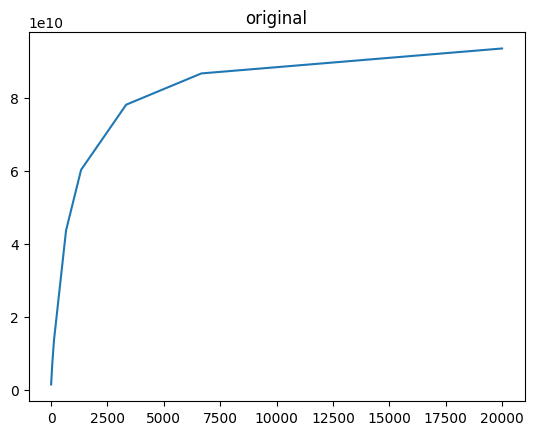

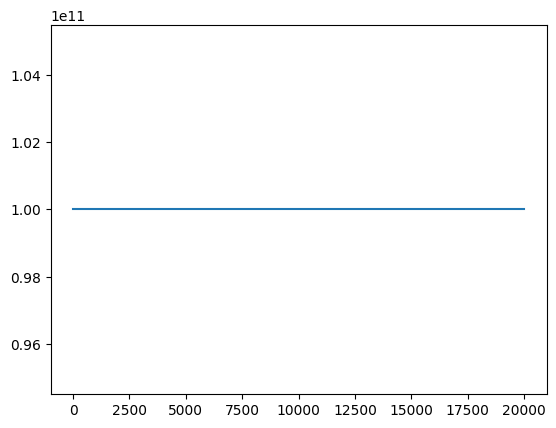

In [6]:
# Load benchmark FCT
flow_size=[0, 6, 13, 19, 33, 53, 133, 667, 1333, 3333, 6667, 20000, float('inf')]
normalize_lists = loadNormalizeList(flow_benchmark_dir, flow_size[1:-1])
plt.plot(normalize_lists[0], normalize_lists[1])
plt.title("original")
plt.show()

original_lists=[flow_size[1:-1],[100 * 1e9 for i in range(len(flow_size) - 2)]]
plt.plot(original_lists[0], original_lists[1])


In [44]:
folder = "./results/weight/1_100_10000/0.9/"
# topo = "Topology-8hosts-NSDI21.tcl"
topo = "Topology-32hosts-NSDI21.tcl"
# topo = "Topology-32hosts-NSDI21.tcl"
flow_num = 1000
flow_num_str = str(flow_num)
# alg_list = ["1x16","2x8","3x5","4x4","5x3"]
# alg_list = ["1x32","2x16","3x10","4x8","5x6"]
alg_list = ["1x100","2x50","3x33","4x25","5x20"]

In [45]:
FCT_analysis_normalize = FCT(folder,
                             topo,
                             flow_num,
                             [0.9],
                             alg_list,
                             normalize_lists)
FCT_analysis_original = FCT(folder, \
                            topo,
                            flow_num,
                            [0.9],
                            alg_list,
                            original_lists)

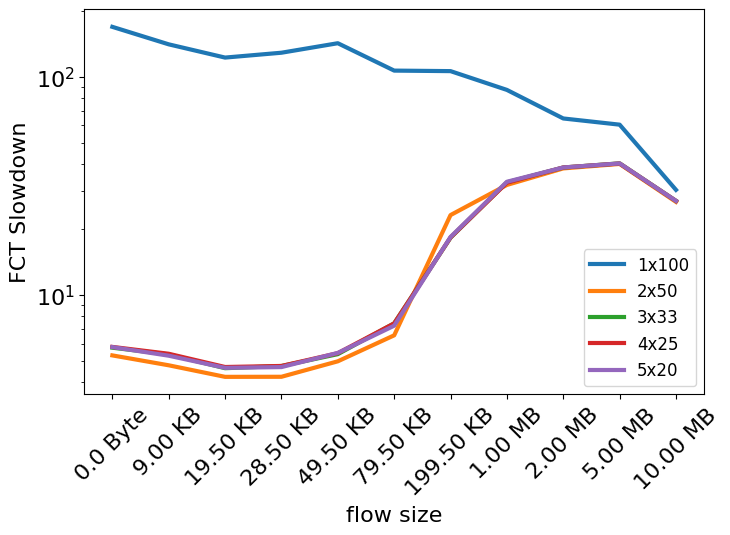

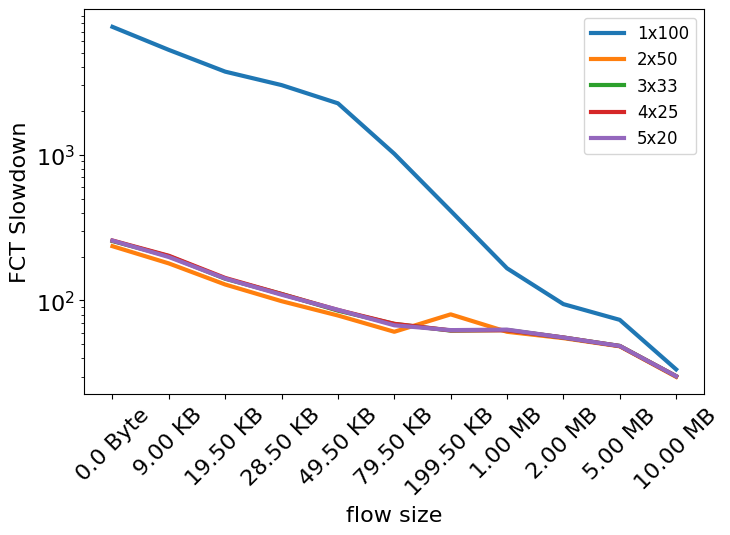

In [46]:
# FCT_analysis_normalize.plot_Mean_FCT_fix_size_by_weight(
#     alg_list, 0.9, flow_size)

# FCT_analysis_original.plot_Mean_FCT_fix_size_by_weight(
#     alg_list, 0.9, flow_size)

FCT_analysis_normalize.plot_Mean_FCT_fix_load_mark(
    alg_list, 0.9, flow_size)

FCT_analysis_original.plot_Mean_FCT_fix_load_mark(
    alg_list, 0.9, flow_size)

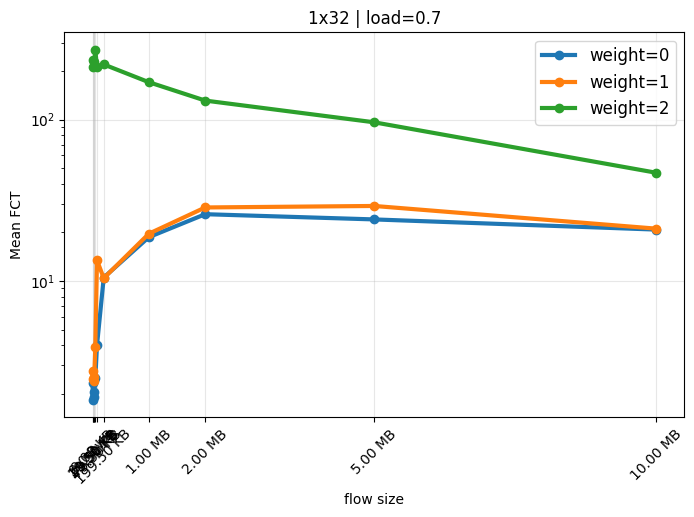

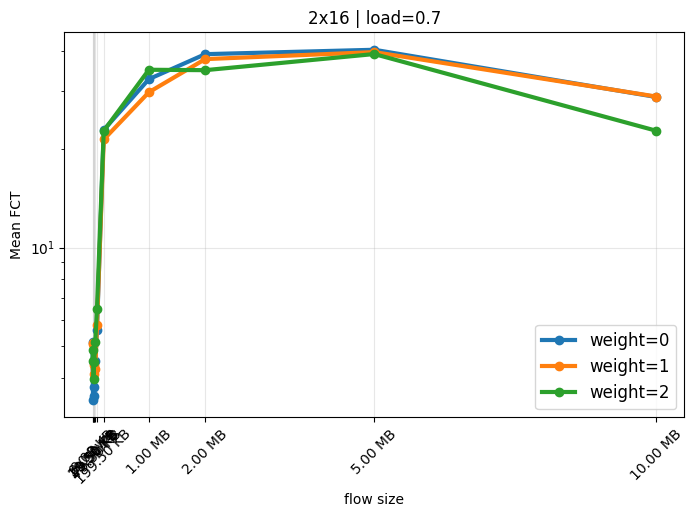

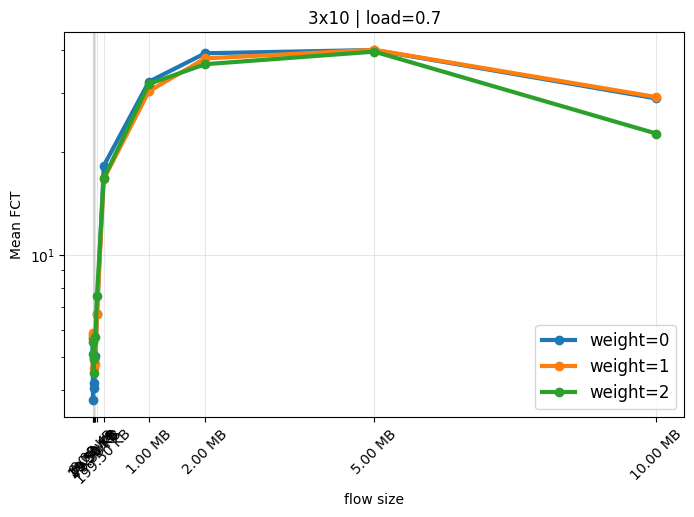

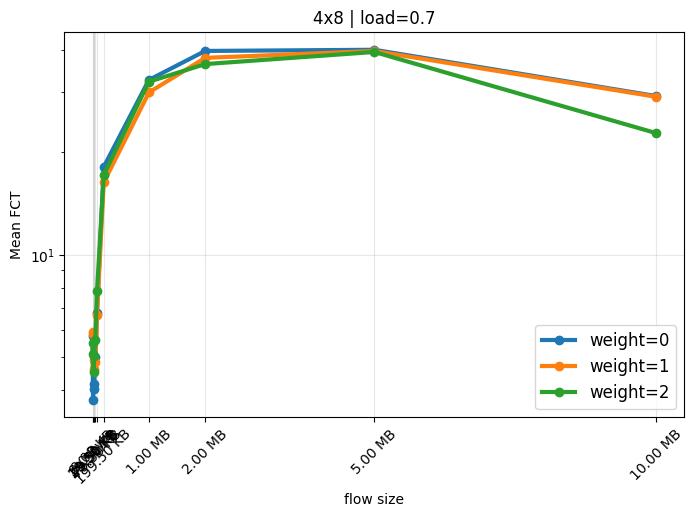

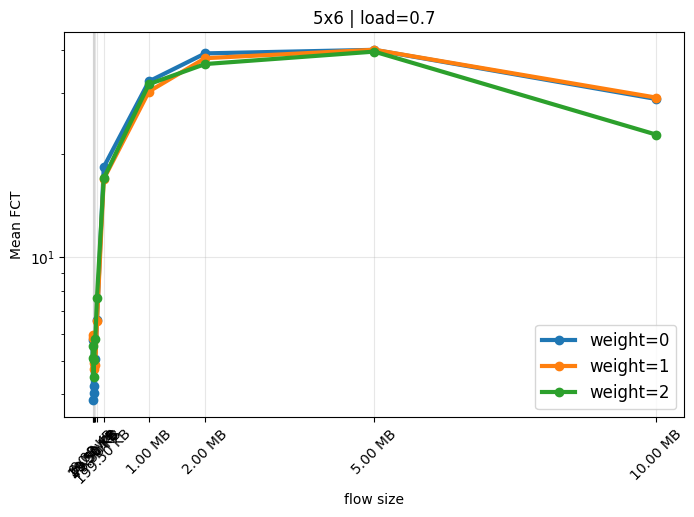

In [9]:
for alg in alg_list:
    FCT_analysis_normalize.plot_Mean_FCT_flow_vs_weight(
        alg, 0.7, flow_size)


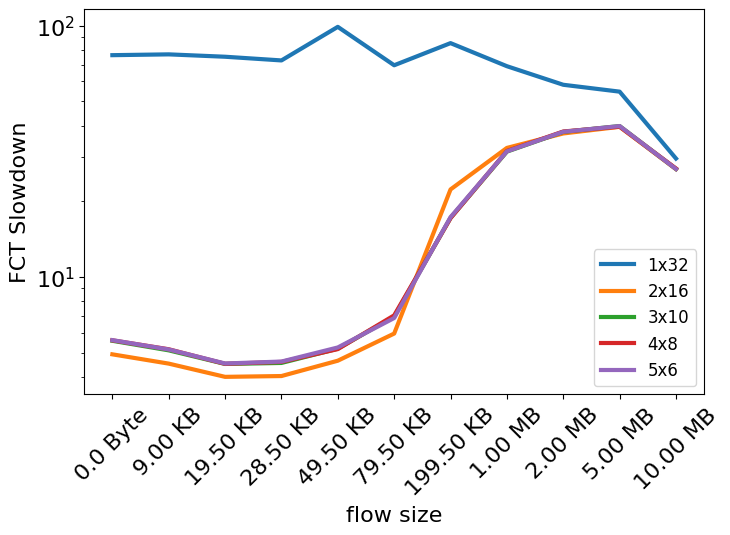

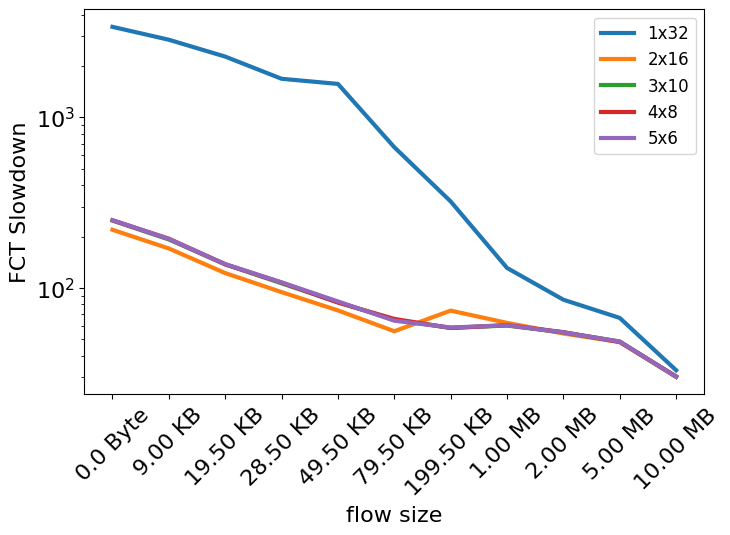

In [10]:
FCT_analysis_normalize.plot_Mean_FCT_fix_load_mark(
    alg_list, 0.7, flow_size)

FCT_analysis_original.plot_Mean_FCT_fix_load_mark(
    alg_list, 0.7, flow_size)

In [21]:
folder = "./no_step_down_results/"
# topo = "Topology-8hosts-NSDI21.tcl"
topo = "Topology-32hosts-NSDI21.tcl"
# topo = "Topology-32hosts-NSDI21.tcl"
flow_num = 1000
flow_num_str = str(flow_num)
alg_list = ["1x32","2x16","3x10","4x8","5x6"]
FCT_analysis_normalize = FCT(folder,
                             topo,
                             flow_num,
                             [0.7],
                             alg_list,
                             normalize_lists)
FCT_analysis_original = FCT(folder, \
                            topo,
                            flow_num,
                            [0.7],
                            alg_list,
                            original_lists)

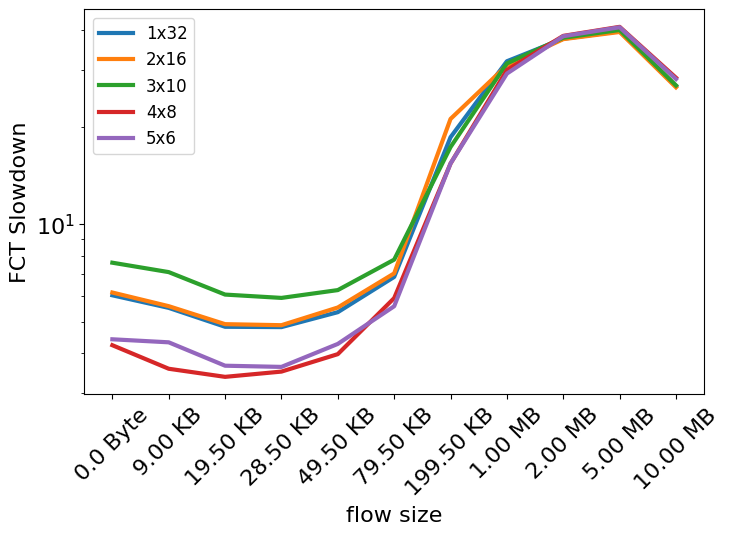

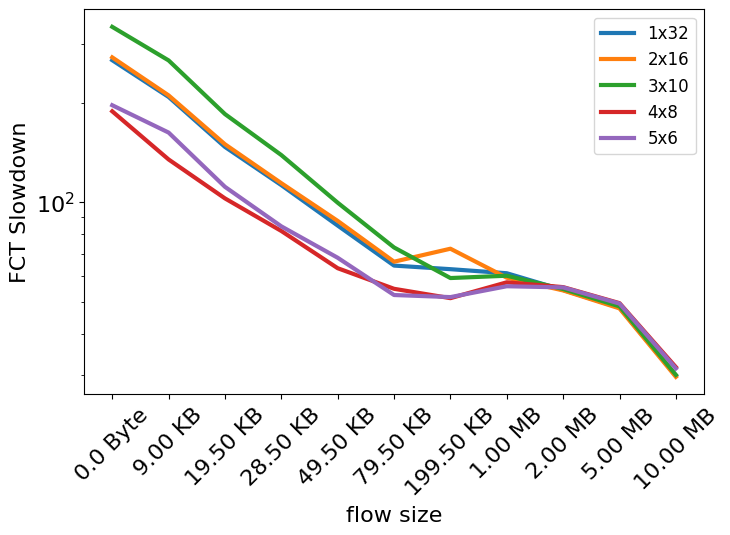

In [23]:
FCT_analysis_normalize.plot_Mean_FCT_fix_load_mark(
    alg_list, 0.7, flow_size)

FCT_analysis_original.plot_Mean_FCT_fix_load_mark(
    alg_list, 0.7, flow_size)

In [9]:
folder = "./original/500_0.7/"
# topo = "Topology-8hosts-NSDI21.tcl"
topo = "Topology-32hosts-NSDI21.tcl"
# topo = "Topology-32hosts-NSDI21.tcl"
flow_num = 500
flow_num_str = str(flow_num)
alg_list = ["1x30","2x16","3x10","4x8","5x6"]
FCT_analysis_normalize = FCT(folder,
                             topo,
                             flow_num,
                             [0.7],
                             alg_list,
                             normalize_lists)
FCT_analysis_original = FCT(folder, \
                            topo,
                            flow_num,
                            [0.7],
                            alg_list,
                            original_lists)

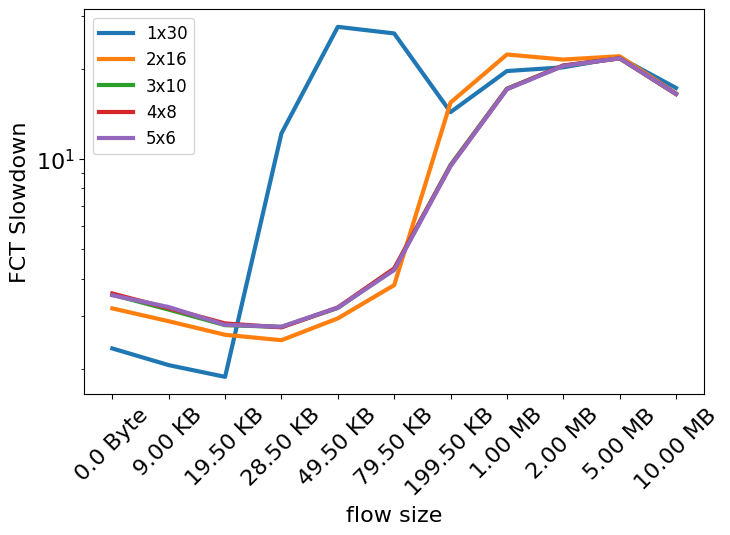

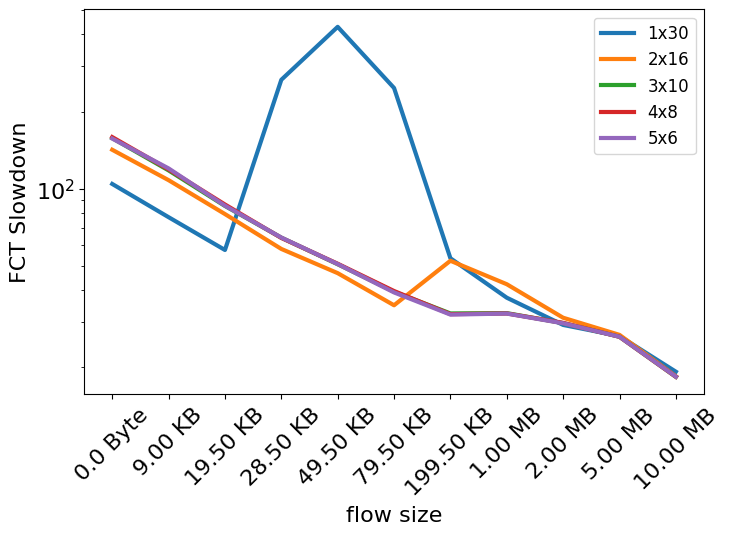

In [11]:
FCT_analysis_normalize.plot_Mean_FCT_fix_load_mark(
    alg_list, 0.7, flow_size)

FCT_analysis_original.plot_Mean_FCT_fix_load_mark(
    alg_list, 0.7, flow_size)

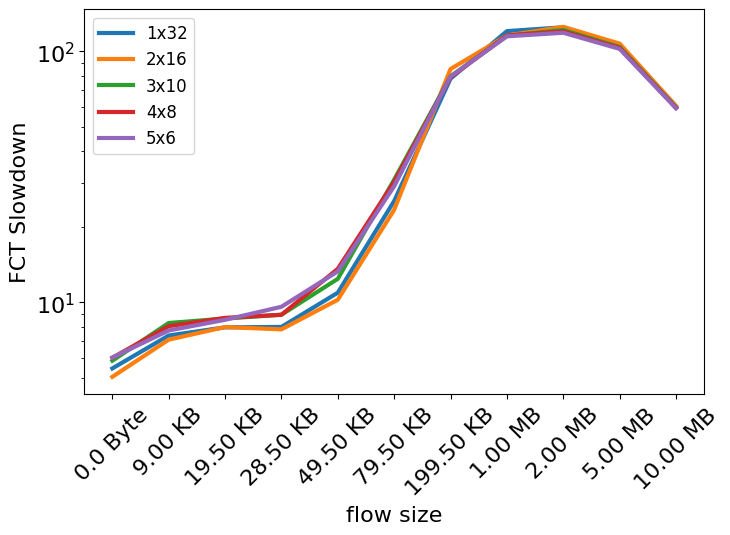

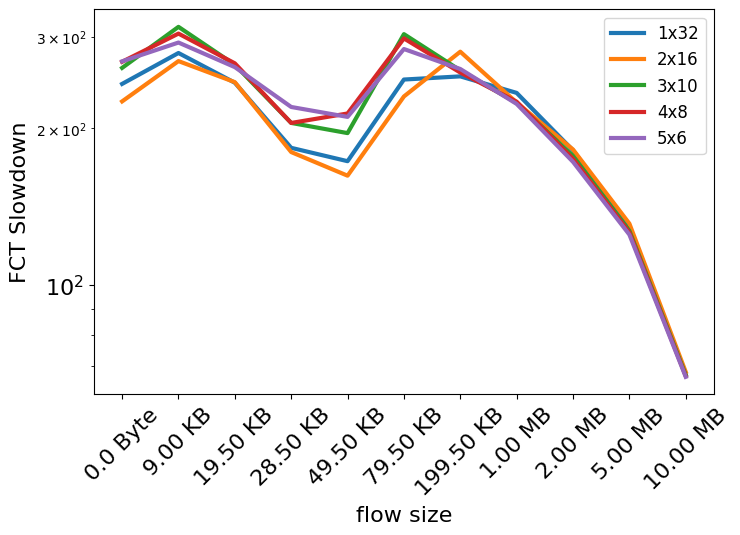

In [12]:
folder = "./results/"
# topo = "Topology-8hosts-NSDI21.tcl"
topo = "Topology-16hosts-NSDI21.tcl"
# topo = "Topology-32hosts-NSDI21.tcl"
flow_num = 500
flow_num_str = str(flow_num)
alg_list = ["1x32","2x16","3x10","4x8","5x6"]
FCT_analysis_normalize = FCT(folder,
                             topo,
                             flow_num,
                             [0.7],
                             alg_list,
                             normalize_lists)
FCT_analysis_original = FCT(folder, \
                            topo,
                            flow_num,
                            [0.7],
                            alg_list,
                            original_lists)

FCT_analysis_normalize.plot_Mean_FCT_fix_load_mark(
    alg_list, 0.7, flow_size)

FCT_analysis_original.plot_Mean_FCT_fix_load_mark(
    alg_list, 0.7, flow_size)

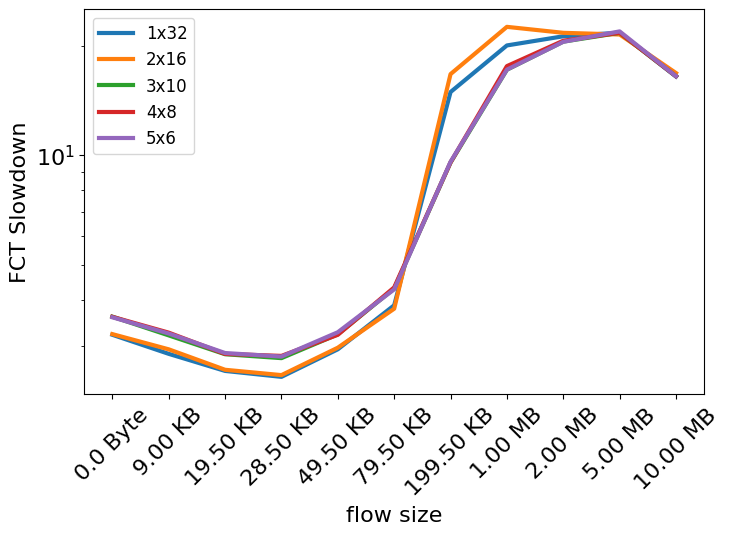

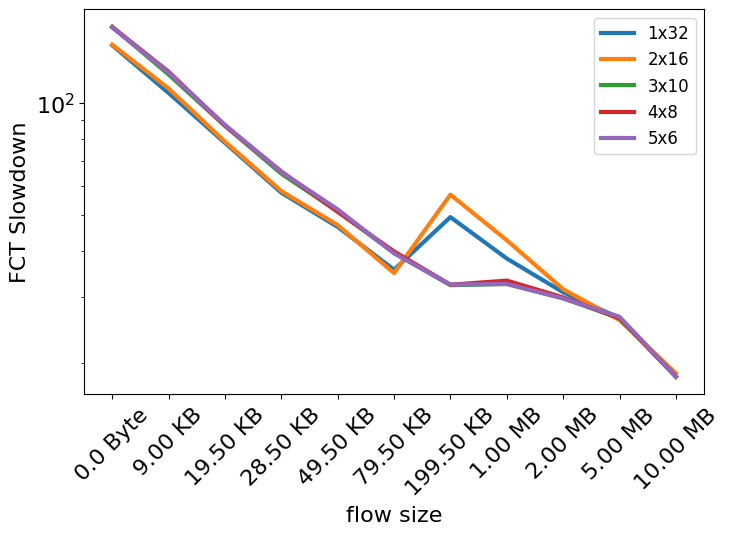

In [17]:
folder = "./compare/"
# topo = "Topology-8hosts-NSDI21.tcl"
topo = "Topology-32hosts-NSDI21.tcl"
# topo = "Topology-32hosts-NSDI21.tcl"
flow_num = 500
flow_num_str = str(flow_num)
alg_list = ["1x32","2x16","3x10","4x8","5x6"]
FCT_analysis_normalize = FCT(folder,
                             topo,
                             flow_num,
                             [0.7],
                             alg_list,
                             normalize_lists)
FCT_analysis_original = FCT(folder, \
                            topo,
                            flow_num,
                            [0.7],
                            alg_list,
                            original_lists)

FCT_analysis_normalize.plot_Mean_FCT_fix_load_mark(
    alg_list, 0.7, flow_size)

FCT_analysis_original.plot_Mean_FCT_fix_load_mark(
    alg_list, 0.7, flow_size)

In [10]:
# Load FCT results
folder = "./New_test_results/"

In [5]:
topo = "Topology-32hosts.tcl"
#topo = "Topology-4hosts-4pods-random.tcl"
flow_num = 1000
flow_num_str = "1000"

In [7]:
topo = "Topology-32hosts.tcl"
flow_num = 500
flow_num_str = "500"

In [ ]:
topo = "Topology-8hosts.tcl"
flow_num = 500
flow_num_str = "500"

In [6]:
"""if __name__ == '__main__':
    folder = "/home/ovs2/lining/Gearbox/automatic/"
    FCT_analysis = FCT(
        [.5], \
        ["AFQ10UlimPL"],\
        [
            folder + "tcp_AFQ10UlimPL_flow_100_0.5_Topology-incast-singlenode.tcl.tr"
        ],\
        normalize_lists)"""

if __name__ == '__main__':
    #folder = "/Users/peixuangao/Documents/NYU/Project/NS2/Hyline/Gearbox-Hyline/data/portland/singlenode/ori_2hostsPerSw/"
    FCT_analysis = FCT(
        [.5], \
        ["AFQ10UlimPL"],\
        [
            #folder + "tcp-incast-AFQ10unlim/" + "tcp_flow_500_0.5_Topology-incast-singlenode.tcl.tr"
            #folder + "tcp-incast-AFQ10unlim/" + "tcp_flow_500_0.5_Topology-32hosts.tcl.tr"
            #folder + "tcp-incast-AFQ10unlim/" + "tcp_flow_500_0.5_Topology-32hosts-NSDI20.tcl.tr"
            #folder + "tcp-incast-AFQ10unlim/" + "tcp_flow_500_0.5_Topology-bw-incast-singlenode.tcl.tr"
            #folder + "tcp-incast-AFQ10unlim/" + "tcp_flow_1000_0.5_Topology-32hosts.tcl.tr"
            #folder + "tcp-incast-AFQ10unlim/" + "tcp_flow_1000_0.5_Topology-4pods-random.tcl.tr"
            #folder + "tcp-incast-AFQ10unlim/" + "tcp_flow_"+flow_num_str+"_0.5_"+topo+".tr"
            folder + "WFQ-PIFO/" + "tcp_flow_"+flow_num_str+"_0.5_"+topo+".tr"

        ],\
        normalize_lists)

In [17]:
# Load scheme list
alg_list = ["CQ-1", "CQ-10", "CQ-100", "WFQ-PIFO", "Gearbox", "DropTail", "Gearbox_Flex_5L", "Gearbox_Flex_4L", "Gearbox_Flex_2L"]


if __name__ == '__main__':
    # automatic folder All
    FCT_analysis_normalize = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.1, .3, .5, .7, .9,], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       normalize_lists)
    FCT_analysis_original = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.1, .3, .5, .7, .9,], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       original_lists)

FileNotFoundError: [Errno 2] No such file or directory: './results/CQ-1tcp_flow_500_0.1_Topology-8hosts-NSDI21.tcl.tr'

In [5]:
folder = "/Users/peixuangao/Desktop/GearboxDiffLevel/NSDI21_10_40_32hosts/10_40_bw_FID/rename/"

In [6]:
topo = "Topology-32hosts-NSDI21.tcl"
flow_num = 1000
flow_num_str = "1000"
alg_list = ["1x24","3x8","4x6","5x5"]

In [7]:
if __name__ == '__main__':
    # automatic folder All
    FCT_analysis_normalize = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.7], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       normalize_lists)
    FCT_analysis_original = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.7], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       original_lists)

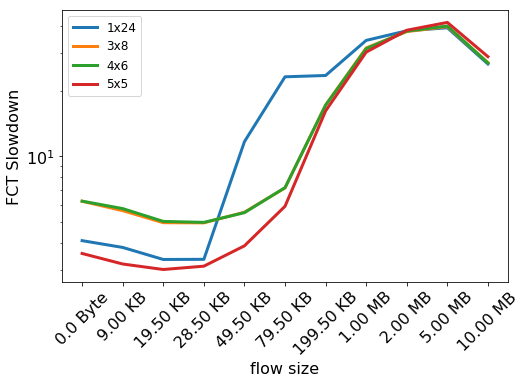

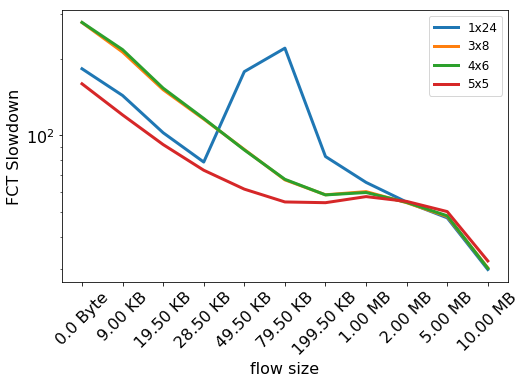

In [8]:
if __name__ == '__main__':
    FCT_analysis_normalize.plot_Mean_FCT_fix_load_mark(
        alg_list, 0.7, flow_size)

    FCT_analysis_original.plot_Mean_FCT_fix_load_mark(
        alg_list, 0.7, flow_size)

In [24]:
folder = "/Users/peixuangao/Desktop/GearboxDiffLevel/NSDI21_10_40_32hosts/10_40_bw_FID/11141011_results/tcp-incast-Gearbox_24fifos/"

In [25]:
topo = "Topology-32hosts-NSDI21.tcl"
flow_num = 1000
flow_num_str = "1000"
alg_list = ["1x24","2x12","3x8","4x6","5x5"]

In [26]:
if __name__ == '__main__':
    # automatic folder All
    FCT_analysis_normalize = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.7], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       normalize_lists)
    FCT_analysis_original = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.7], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       original_lists)

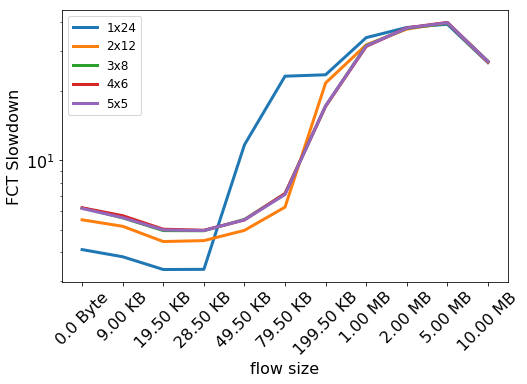

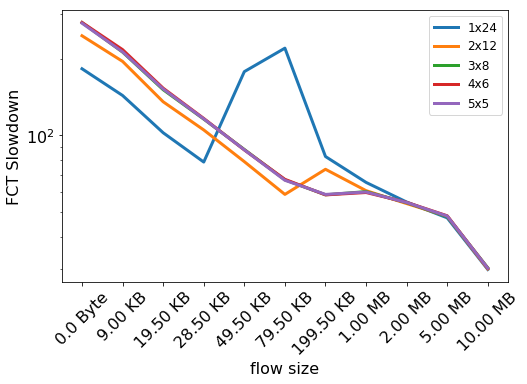

In [27]:
if __name__ == '__main__':
    FCT_analysis_normalize.plot_Mean_FCT_fix_load_mark(
        alg_list, 0.7, flow_size)

    FCT_analysis_original.plot_Mean_FCT_fix_load_mark(
        alg_list, 0.7, flow_size)

In [14]:
folder = "/Users/peixuangao/Desktop/GearboxDiffLevel/NSDI21_10_40_32hosts/10_40_bw_FID/11141011_results/tcp-incast-Gearbox_32fifos/"

In [15]:
topo = "Topology-32hosts-NSDI21.tcl"
flow_num = 1000
flow_num_str = "1000"
alg_list = ["1x30","2x16","3x10","4x8","5x6"]

In [16]:
if __name__ == '__main__':
    # automatic folder All
    FCT_analysis_normalize = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.7], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       normalize_lists)
    FCT_analysis_original = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.7], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       original_lists)

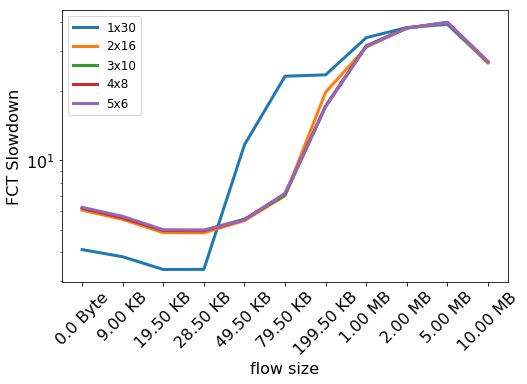

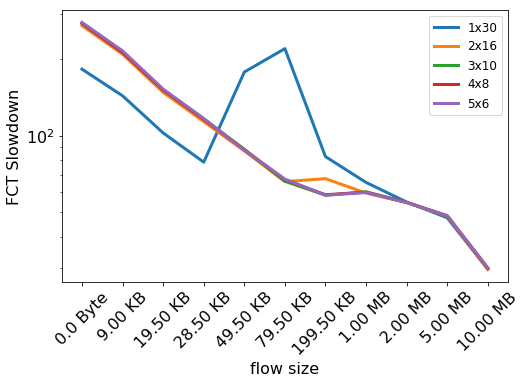

In [17]:
if __name__ == '__main__':
    FCT_analysis_normalize.plot_Mean_FCT_fix_load_mark(
        alg_list, 0.7, flow_size)

    FCT_analysis_original.plot_Mean_FCT_fix_load_mark(
        alg_list, 0.7, flow_size)

In [18]:
folder = "/Users/peixuangao/Desktop/GearboxDiffLevel/NSDI21_10_40_32hosts/10_40_bw_FID/11141011_results/tcp-incast-Gearbox_32fifos_fifosize20/"

In [19]:
topo = "Topology-32hosts-NSDI21.tcl"
flow_num = 1000
flow_num_str = "1000"
alg_list = ["1x30","2x16","3x10","4x8","5x6"]

In [20]:
if __name__ == '__main__':
    # automatic folder All
    FCT_analysis_normalize = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.7], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       normalize_lists)
    FCT_analysis_original = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.7], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       original_lists)

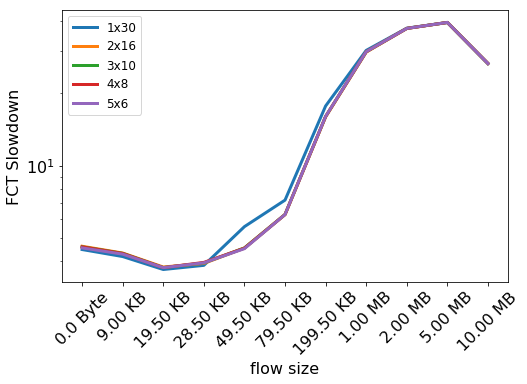

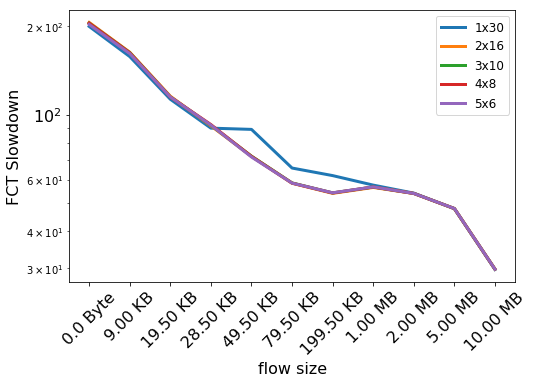

In [21]:
if __name__ == '__main__':
    FCT_analysis_normalize.plot_Mean_FCT_fix_load_mark(
        alg_list, 0.7, flow_size)

    FCT_analysis_original.plot_Mean_FCT_fix_load_mark(
        alg_list, 0.7, flow_size)

In [17]:
folder = "/Users/peixuangao/Desktop/GearboxDiffLevel/NSDI21_10_40_32hosts/10_40_bw_FID/11212022_results/weight4/"

In [18]:
topo = "Topology-32hosts-NSDI21.tcl"
flow_num = 1000
flow_num_str = "1000"
alg_list = ["1x30","2x16","3x10","4x8","5x6"]

In [19]:
if __name__ == '__main__':
    # automatic folder All
    FCT_analysis_normalize = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.7], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       normalize_lists)
    FCT_analysis_original = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.7], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       original_lists)

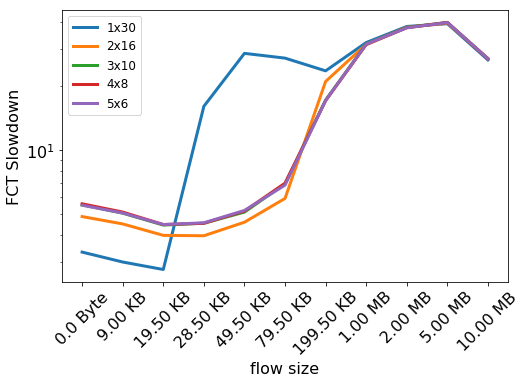

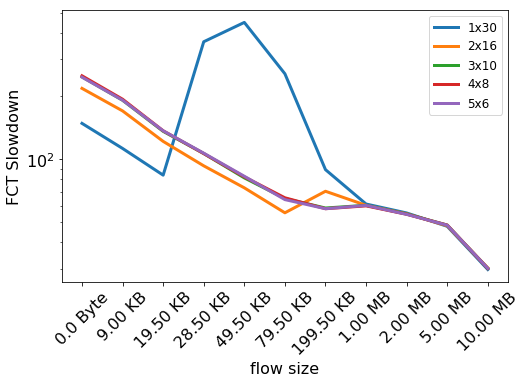

In [20]:
if __name__ == '__main__':
    FCT_analysis_normalize.plot_Mean_FCT_fix_load_mark(
        alg_list, 0.7, flow_size)

    FCT_analysis_original.plot_Mean_FCT_fix_load_mark(
        alg_list, 0.7, flow_size)

In [21]:
topo = "Topology-32hosts-NSDI21.tcl"
flow_num = 500
flow_num_str = "500"
alg_list = ["1x30","2x16","3x10","4x8","5x6"]

In [10]:
if __name__ == '__main__':
    # automatic folder All
    FCT_analysis_normalize = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.7, .9], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       normalize_lists)
    FCT_analysis_original = FCT(folder, \
                       #"Topology-incast-singlenode.tcl",\
                       #"Topology-32hosts.tcl",\
                       #"Topology-32hosts-NSDI20.tcl",\
                       #"Topology-bw-incast-singlenode.tcl",\
                       #"Topology-4pods-random.tcl",\
                       topo,\
                       #500, \
                       #1000, \
                       flow_num,\
                       [.7, .9], \
                       #["DropTail", "AFQ10UlimPL", "AFQ10PL", "AFQ100PL", "AFQ1000PL", "HRCCPL"],\
                       alg_list,\
                       original_lists)

FileNotFoundError: [Errno 2] No such file or directory: './results1x32/tcp_flow_500_0.5_Topology-8hosts-NSDI21.tcl.tr'

In [11]:
if __name__ == '__main__':
    FCT_analysis_normalize.plot_Mean_FCT_fix_load_mark(
        alg_list, 0.7, flow_size)

    FCT_analysis_original.plot_Mean_FCT_fix_load_mark(
        alg_list, 0.7, flow_size)

NameError: name 'FCT_analysis_normalize' is not defined